# 20 · Comparativa final + walk-forward

Compara todos los modelos sobre el mismo split (test 2022-2024) y anade una **validacion walk-forward** del modelo ganador para comprobar su estabilidad temporal.

Lee `results/*_metrics.csv` (formato: `modelo, cod_municipio, mae, mape, rmse, r2`).


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("data")
RESULTS = Path("results")

files = sorted(RESULTS.glob("*_metrics.csv"))
dfs = [pd.read_csv(f) for f in files]
res = pd.concat(dfs, ignore_index=True)
print("modelos:", sorted(res["modelo"].unique()))
print("municipios por modelo:", res.groupby("modelo")["cod_municipio"].nunique().to_dict())


modelos: ['arima', 'ets', 'gb_municipio', 'gb_panel', 'gb_temporal', 'lasso', 'media', 'naive', 'regla_negocio', 'ridge']
municipios por modelo: {'arima': 67, 'ets': 67, 'gb_municipio': 67, 'gb_panel': 67, 'gb_temporal': 67, 'lasso': 67, 'media': 67, 'naive': 67, 'regla_negocio': 67, 'ridge': 67}


In [2]:
# ── Tabla comparativa agregada ────────────────────────────────────────────────
resumen = res.groupby("modelo")[["mae", "mape", "rmse", "r2"]].mean().round(3)
resumen.sort_values("mape")


,mae,mape,rmse,r2
modelo,,,,
gb_municipio,0.121,8.685,0.131,-21.488
regla_negocio,0.182,10.240,0.192,-21.441
naive,0.212,11.557,0.226,-27.043
ets,0.209,11.673,0.224,-37.402
gb_temporal,0.213,11.745,0.226,-30.590
arima,0.221,12.198,0.235,-32.234
ridge,0.217,13.489,0.235,-68.949
media,0.210,17.772,0.219,-131.101
gb_panel,0.157,25.883,0.168,-349.389


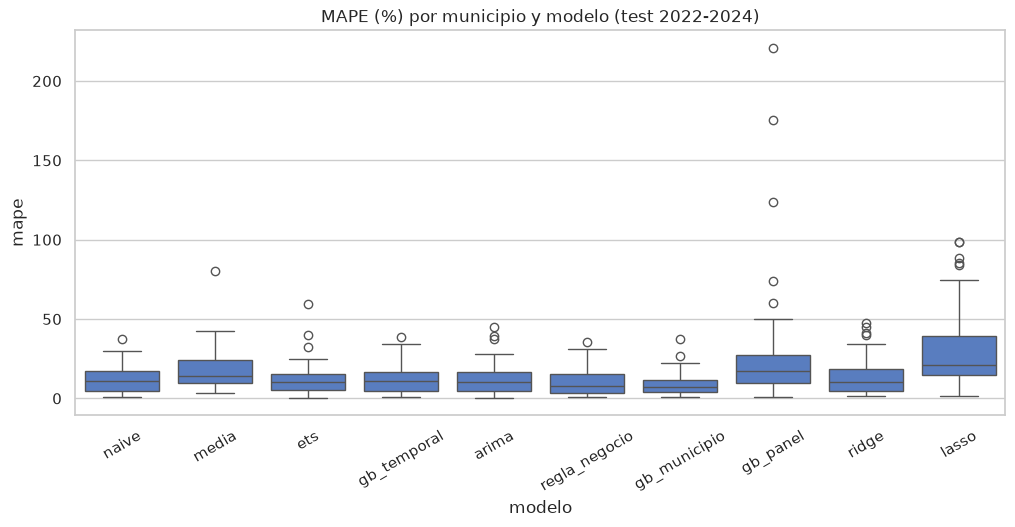

modelo
regla_negocio    14
ridge            13
gb_municipio     11
gb_panel         11
gb_temporal       6
lasso             4
naive             4
arima             3
ets               1
Name: municipios ganados, dtype: int64


In [3]:
# ── Distribucion del MAPE por modelo ──────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.boxplot(data=res, x="modelo", y="mape")
plt.title("MAPE (%) por municipio y modelo (test 2022-2024)")
plt.xticks(rotation=30)
plt.show()

best = res.loc[res.groupby("cod_municipio")["mape"].idxmin()]
print(best.groupby("modelo").size().rename("municipios ganados").sort_values(ascending=False))


In [4]:
# ── Rendimiento por tamano de municipio ───────────────────────────────────────
abast = pl.read_csv(DATA / "abastecimiento_urbano_baleares.csv", infer_schema_length=None).select(["cod_municipio", "anio", "consumo_hm3"])
consumo_test = (abast.filter(pl.col("anio") >= 2022)
                .group_by("cod_municipio").agg(pl.col("consumo_hm3").mean().alias("consumo_medio_hm3"))
                .to_pandas())
cmp = res.merge(consumo_test, on="cod_municipio")
cmp["tamano"] = pd.qcut(cmp["consumo_medio_hm3"], 3, labels=["pequeno", "mediano", "grande"])
piv = cmp.pivot_table(index="modelo", columns="tamano", values="mape", aggfunc="mean").round(1)
piv[["pequeno", "mediano", "grande"]]


tamano,pequeno,mediano,grande
modelo,,,
arima,7.7,11.1,17.9
ets,8.0,11.0,16.1
gb_municipio,7.3,10.5,8.4
gb_panel,48.4,16.7,11.5
gb_temporal,7.4,11.6,16.5
lasso,54.5,19.2,14.5
media,17.8,19.9,15.6
naive,7.8,10.7,16.3
regla_negocio,7.0,9.6,14.3


In [5]:
# ── Walk-forward del modelo ganador (gb_municipio) ────────────────────────────
panel = pl.read_parquet(DATA / "panel_features.parquet")
meta = json.loads((DATA / "panel_metadata.json").read_text())
FEATURES = meta["features"]
TRAIN_DESDE = meta.get("train_desde", 2016)

def walk_forward(anio_test):
    """Entrena con todo lo anterior a anio_test y evalua ese unico anio (1 paso)."""
    mapes, mapes_naive = [], []
    for cod_t, g in panel.partition_by("cod_municipio", as_dict=True).items():
        cod = int(cod_t[0])
        train = g.filter((pl.col("anio") >= TRAIN_DESDE) & (pl.col("anio") < anio_test) & pl.col("lag1").is_not_null())
        test = g.filter(pl.col("anio") == anio_test)
        if train.height < 4 or test.height == 0:
            continue
        m = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
        m.fit(train.select(FEATURES).to_numpy(), train["consumo_hm3"].to_numpy())
        x = test.select(FEATURES).to_numpy()[0]
        pred = max(float(m.predict([x])[0]), 0.0)
        real = float(test["consumo_hm3"].to_numpy()[0])
        mapes.append(abs((real - pred) / real) * 100)
        mapes_naive.append(abs((real - float(x[FEATURES.index("lag1")])) / real) * 100)
    return np.mean(mapes), np.mean(mapes_naive)

anios = [2021, 2022, 2023, 2024]
wf = pd.DataFrame(
    [{"anio_test": a, "gb_municipio": walk_forward(a)[0], "naive": walk_forward(a)[1]} for a in anios]
)
wf.round(2)


,anio_test,gb_municipio,naive
0,2021,6.01,7.52
1,2022,6.27,8.72
2,2023,6.05,5.28
3,2024,6.07,5.53


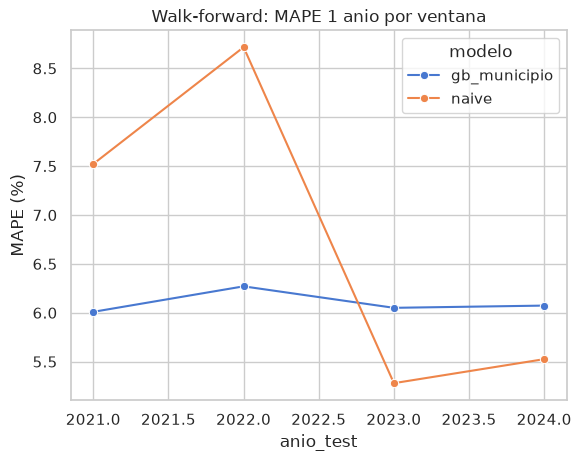

In [6]:
wf_m = wf.melt("anio_test", var_name="modelo", value_name="mape")
sns.lineplot(data=wf_m, x="anio_test", y="mape", hue="modelo", marker="o")
plt.title("Walk-forward: MAPE 1 anio por ventana")
plt.ylabel("MAPE (%)")
plt.show()


**Conclusiones para negocio**

1. **Modelo recomendado**: el que gane en MAPE agregado y en `municipios ganados` (esperado: `gb_municipio`).
2. **Cota de negocio**: si `regla_negocio` queda cerca, hay que explicar el coste/beneficio del ML (mantenimiento, reentrenamiento).
3. **Estabilidad**: el walk-forward muestra si el modelo se sostiene fuera del split principal (si el MAPE es similar en cada ventana, es estable).
4. **Tamano**: los modelos complejos suelen aportar mas en municipios grandes (mas senal de IPH/ocupacion); en pequenos el naive puede bastar.
